In [1]:
from pathlib import Path
from datetime import datetime, timedelta
import time

import requests
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
lat_min, lat_max = 45, 49
lon_min, lon_max = -109, -100
year = 2017
scale = "4WK"

In [3]:

download_dir = Path(f"data/raw/esi/{year}_{scale}")
download_dir.mkdir(parents=True, exist_ok=True)

print(download_dir.resolve())

/data/keeling/a/marygan2/Capstone/Semester2/2017/data/raw/esi/2017_4WK


In [4]:
from datetime import datetime, timedelta
from pathlib import Path
import time

import requests
import pandas as pd
import xarray as xr
import rioxarray as rxr


# =========================
# User settings
# =========================
lat_min, lat_max = 45, 49
lon_min, lon_max = -109, -100

year = 2017
scale = "4WK"
product = "DFPPM"

download_dir = Path(f"data/raw/esi/{year}_{scale}")
download_dir.mkdir(parents=True, exist_ok=True)


# =========================
# Helpers
# =========================
def daterange_step(start_date, end_date, step_days=7):
    current = start_date
    while current <= end_date:
        yield current
        current += timedelta(days=step_days)


def build_esi_url(date_obj, scale="4WK", product="DFPPM"):
    """
    Example:
    https://gis1.servirglobal.net/data/esi/4WK/2017/DFPPM_4WK_2017008.tif
    """
    year = date_obj.strftime("%Y")
    doy = date_obj.timetuple().tm_yday
    fname = f"{product}_{scale}_{year}{doy:03d}.tif"
    url = f"https://gis1.servirglobal.net/data/esi/{scale}/{year}/{fname}"
    return url, fname


def download_file(url, out_path, timeout=60):
    r = requests.get(url, stream=True, timeout=timeout)
    if r.status_code != 200:
        return r.status_code, False

    with open(out_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    return r.status_code, True


def open_and_clip_tif(path, lon_min, lat_min, lon_max, lat_max):
    da = rxr.open_rasterio(path, masked=True).squeeze()

    # Most GeoTIFFs should already have CRS, but set it if missing
    if da.rio.crs is None:
        da = da.rio.write_crs("EPSG:4326")

    da = da.rio.clip_box(
        minx=lon_min,
        miny=lat_min,
        maxx=lon_max,
        maxy=lat_max
    )

    da = da.rename({"x": "lon", "y": "lat"})

    # Remove leftover scalar band coord if present
    if "band" in da.coords:
        da = da.reset_coords("band", drop=True)

    return da


# =========================
# Download ESI files
# =========================
start = datetime(year, 1, 1)
end   = datetime(year, 12, 31)

download_log = []

for dt in daterange_step(start, end, step_days=7):
    url, fname = build_esi_url(dt, scale=scale, product=product)
    out_path = download_dir / fname

    if out_path.exists():
        download_log.append({
            "date_requested": dt.strftime("%Y-%m-%d"),
            "filename": fname,
            "status_code": 200,
            "downloaded_now": False,
            "exists_local": True
        })
        continue

    try:
        status_code, ok = download_file(url, out_path)
        download_log.append({
            "date_requested": dt.strftime("%Y-%m-%d"),
            "filename": fname,
            "status_code": status_code,
            "downloaded_now": ok,
            "exists_local": out_path.exists()
        })
    except Exception as e:
        download_log.append({
            "date_requested": dt.strftime("%Y-%m-%d"),
            "filename": fname,
            "status_code": None,
            "downloaded_now": False,
            "exists_local": False,
            "error": str(e)
        })

    time.sleep(0.1)

download_df = pd.DataFrame(download_log)
print(download_df["status_code"].value_counts(dropna=False))
print(f"\nFiles on disk: {len(list(download_dir.glob('*.tif')))}")
download_df.head()

status_code
200    52
404     1
Name: count, dtype: int64

Files on disk: 52


,date_requested,filename,status_code,downloaded_now,exists_local
0,2017-01-01,DFPPM_4WK_2017001.tif,404,False,False
1,2017-01-08,DFPPM_4WK_2017008.tif,200,False,True
2,2017-01-15,DFPPM_4WK_2017015.tif,200,False,True
3,2017-01-22,DFPPM_4WK_2017022.tif,200,False,True
4,2017-01-29,DFPPM_4WK_2017029.tif,200,False,True


In [5]:
download_df.sort_values("date_requested").tail(10)


,date_requested,filename,status_code,downloaded_now,exists_local
43,2017-10-29,DFPPM_4WK_2017302.tif,200,False,True
44,2017-11-05,DFPPM_4WK_2017309.tif,200,False,True
45,2017-11-12,DFPPM_4WK_2017316.tif,200,True,True
46,2017-11-19,DFPPM_4WK_2017323.tif,200,True,True
47,2017-11-26,DFPPM_4WK_2017330.tif,200,True,True
48,2017-12-03,DFPPM_4WK_2017337.tif,200,True,True
49,2017-12-10,DFPPM_4WK_2017344.tif,200,True,True
50,2017-12-17,DFPPM_4WK_2017351.tif,200,True,True
51,2017-12-24,DFPPM_4WK_2017358.tif,200,True,True
52,2017-12-31,DFPPM_4WK_2017365.tif,200,True,True


In [6]:
files = sorted(download_dir.glob("*.tif"))
print(f"Found {len(files)} files")
files[:5], files[-5:]

Found 52 files


([PosixPath('data/raw/esi/2017_4WK/DFPPM_4WK_2017008.tif'),
  PosixPath('data/raw/esi/2017_4WK/DFPPM_4WK_2017015.tif'),
  PosixPath('data/raw/esi/2017_4WK/DFPPM_4WK_2017022.tif'),
  PosixPath('data/raw/esi/2017_4WK/DFPPM_4WK_2017029.tif'),
  PosixPath('data/raw/esi/2017_4WK/DFPPM_4WK_2017036.tif')],
 [PosixPath('data/raw/esi/2017_4WK/DFPPM_4WK_2017337.tif'),
  PosixPath('data/raw/esi/2017_4WK/DFPPM_4WK_2017344.tif'),
  PosixPath('data/raw/esi/2017_4WK/DFPPM_4WK_2017351.tif'),
  PosixPath('data/raw/esi/2017_4WK/DFPPM_4WK_2017358.tif'),
  PosixPath('data/raw/esi/2017_4WK/DFPPM_4WK_2017365.tif')])

In [7]:
data_arrays = []

for f in files:
    try:
        da = open_and_clip_tif(
            f,
            lon_min=lon_min,
            lat_min=lat_min,
            lon_max=lon_max,
            lat_max=lat_max
        )

        # Parse YYYYDOY from filename, e.g. DFPPM_4WK_2017008.tif
        yyyydoy = f.stem.split("_")[-1]
        dt = pd.to_datetime(yyyydoy, format="%Y%j")

        da = da.expand_dims(time=[dt])
        data_arrays.append(da)

    except Exception as e:
        print(f"Skipping {f.name}: {e}")

Skipping DFPPM_4WK_2017309.tif: Read failed. See previous exception for details.


In [8]:
esi_4wk = xr.concat(data_arrays, dim="time").sortby("time")
esi_4wk.name = "ESI_4WK"

esi_4wk

<xarray.DataArray 'ESI_4WK' (time: 51, lat: 80, lon: 180)> Size: 3MB
array([[[-1.1667353e+00, -9.4663221e-01, -4.1998667e-01, ...,
          3.6262482e-01, -9.9990000e+03, -9.9990000e+03],
        [-1.0050766e+00, -6.7199564e-01, -9.9990000e+03, ...,
          1.5296490e-01,  5.2998400e-01, -9.9990000e+03],
        [-7.8691709e-01, -1.9185394e-01, -2.7837315e-01, ...,
          6.0938299e-01,  4.5385924e-01, -4.5260098e-02],
        ...,
        [ 8.7470931e-01,  9.3510085e-01,  9.1769993e-01, ...,
          1.0410062e+00, -4.3152502e-01,  1.3818294e+00],
        [ 7.9381794e-01,  5.1501441e-01,  1.0274047e+00, ...,
          1.9352901e+00,  4.8948523e-01,  2.8001750e+00],
        [ 6.4496559e-01,  7.7286541e-01,  8.8406783e-01, ...,
          1.0642911e+00,  1.6749432e+00, -9.9990000e+03]],

       [[-8.2393056e-01, -7.2572243e-01, -3.4322271e-01, ...,
          3.1058356e-01, -9.9990000e+03, -9.9990000e+03],
        [-1.1115516e+00, -8.1275445e-01, -9.9990000e+03, ...,
          5.0218576e-01,  8.9127260e-01, -9.9990000e+03],
        [-8.4552342e-01, -5.4741645e-01,  6.6034997e-01, ...,
          4.7011200e-01,  5.1741737e-01,  2.9707471e-01],
...
         -3.0416402e-01, -1.1427251e+00, -1.0706291e+00],
        [-2.2041976e+00, -2.3544638e+00, -1.8552990e+00, ...,
         -1.4448254e-01, -3.1093845e-02, -2.3676306e-02],
        [-2.0059500e+00, -1.5749995e+00, -1.4627573e+00, ...,
          3.7928276e-02,  4.2000601e-01,  2.7762857e-01]],

       [[-2.5350895e+00, -2.6587670e+00, -2.5974565e+00, ...,
          3.7957972e-01,  3.4831852e-01,  6.1321384e-01],
        [-2.7091305e+00, -2.4298501e+00, -2.8135362e+00, ...,
         -5.6834470e-02,  9.3536925e-01,  4.7804642e-01],
        [-2.3807428e+00, -1.9560934e+00, -2.3666630e+00, ...,
          3.2548055e-01,  7.7092385e-01,  6.6165894e-01],
        ...,
        [-2.0793712e+00, -2.0184834e+00, -1.9817655e+00, ...,
          3.5439110e-01, -3.6108240e-01, -3.4147197e-01],
        [-2.2069001e+00, -2.1265628e+00, -1.6659293e+00, ...,
          3.9683971e-01,  5.5435467e-01,  5.9542316e-01],
        [-1.6871027e+00, -1.4242843e+00, -1.1390101e+00, ...,
          5.2057809e-01,  9.3156981e-01,  7.3052609e-01]]],
      shape=(51, 80, 180), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 408B 2017-01-08 2017-01-15 ... 2017-12-31
  * lon          (lon) float64 1kB -109.0 -108.9 -108.9 ... -100.1 -100.1 -100.0
  * lat          (lat) float64 640B 48.97 48.92 48.87 ... 45.12 45.07 45.02
    spatial_ref  int64 8B 0
Attributes:
    DataType:            Generic
    AREA_OR_POINT:       Area
    RepresentationType:  ATHEMATIC
    scale_factor:        1.0
    add_offset:          0.0

In [9]:
print("Time range:")
print(esi_4wk.time.min().values, "to", esi_4wk.time.max().values)

print("\nLat range:")
print(float(esi_4wk.lat.min().values), "to", float(esi_4wk.lat.max().values))

print("\nLon range:")
print(float(esi_4wk.lon.min().values), "to", float(esi_4wk.lon.max().values))

Time range:
2017-01-08T00:00:00.000000000 to 2017-12-31T00:00:00.000000000

Lat range:
45.02499999999999 to 48.974999999999994

Lon range:
-108.975 to -100.02499999999999


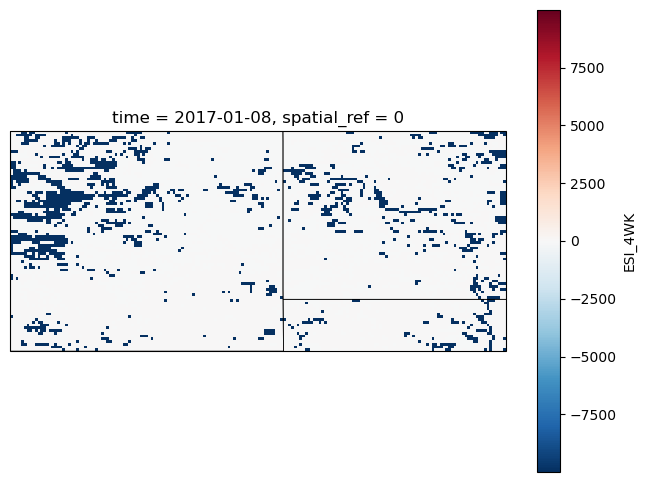

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

esi_4wk.isel(time=0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r'
)

ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.COASTLINE)

ax.set_extent([-109, -100, 45, 49])  # optional (your SE U.S. box)

plt.show()


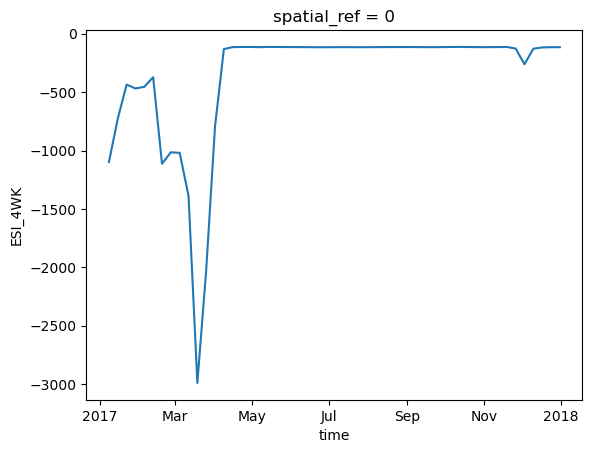

In [12]:
esi_regional_mean = esi_4wk.mean(dim=("lat", "lon"))
esi_regional_mean.plot()

In [ ]:
esi_regional_mean.plot(figsize=(10, 4))

In [ ]:
esi_subset = esi_regional_mean.sel(time=slice("2017-05-01", "2017-12-31"))
esi_subset.plot(figsize=(10, 4))